# Chapter 4: Integration on Manifolds

**Source Span.** `Foundations of Differentiable Manifolds and Lie Groups.pdf` printed pages `138-162`, covering orientation, integration on manifolds, Stokes-type constructions, integration on Riemannian manifolds and Lie groups, de Rham cohomology, the Poincare lemma, and exercises.

**Chapter Goal.** Connect differential forms to integrals and cohomology. Orientation selects signs for top forms and boundaries. Pullbacks allow forms to be integrated over singular chains and coordinate domains. Stokes theorem relates interior derivatives to boundary integrals. de Rham cohomology records closed forms modulo exact forms, and the Poincare lemma explains why the obstruction is global rather than local.

The notebook uses explicit checks for orientation sign, pullback integration, Stokes on a disk, a closed non-exact angular form, and a de Rham dependency graph. It is tailored to Warner's integration/de Rham chapter while avoiding copied exposition or figures.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
import plotly.graph_objects as go
BOOK_ROOT=None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists(): BOOK_ROOT=candidate; break
if BOOK_ROOT is None: raise RuntimeError('book root not found')
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
UNIT_KEY='chapter-04-integration-on-manifolds'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES,HTML,CHECKS,TABLES=(ARTIFACT_ROOT/name for name in ['figures','html','checks','tables'])
TRACKED_ARTIFACTS=[]
print(f'Book root: {BOOK_ROOT}')


Book root: D:\Geometry\Foundations-of-Differentiable-Manifolds-and-Lie-Groups


## Visual Storyboard

1. **Orientation and boundary signs.** Ordered frames and interval/disk boundary orientations are shown with determinant signs.
2. **Pullback integration lab.** A two-form is pulled back by an affine chart and integrated on the source; the result matches the target-domain integral.
3. **Stokes theorem on a disk.** A one-form with `d omega` equal to area form is integrated over boundary and interior.
4. **de Rham obstruction.** The angular form on the punctured plane is closed but has nonzero period, so it is not exact.
5. **Proof flow.** Orientation, singular chains, Stokes, Poincare lemma, and de Rham cohomology are connected.

## Library Routing

| Concept | Representation | Library | Why it fits | Check |
| --- | --- | --- | --- | --- |
| Orientation | Determinant/boundary signs | Matplotlib + NumPy | Integration signs are visual and algebraic | determinant sign table |
| Pullback integration | Affine chart and two-form | Plotly + NumPy | Warner integrates in charts/chains | source-target integral residual |
| Stokes | Disk and oriented boundary | Matplotlib + SymPy | Central theorem needs boundary geometry | residual near zero and `d^2=0` |
| de Rham class | Angular form period | Plotly + NumPy | Cohomology obstruction is a loop integral | period equals `2pi` |


## Orientation And Pullback Integration

Orientation determines which top-degree forms integrate positively. A coordinate change contributes the sign of its determinant. Pullback is the operational way to integrate a form over a parametrized chain or coordinate patch: move the form to the parameter domain, include the Jacobian determinant, and integrate there.


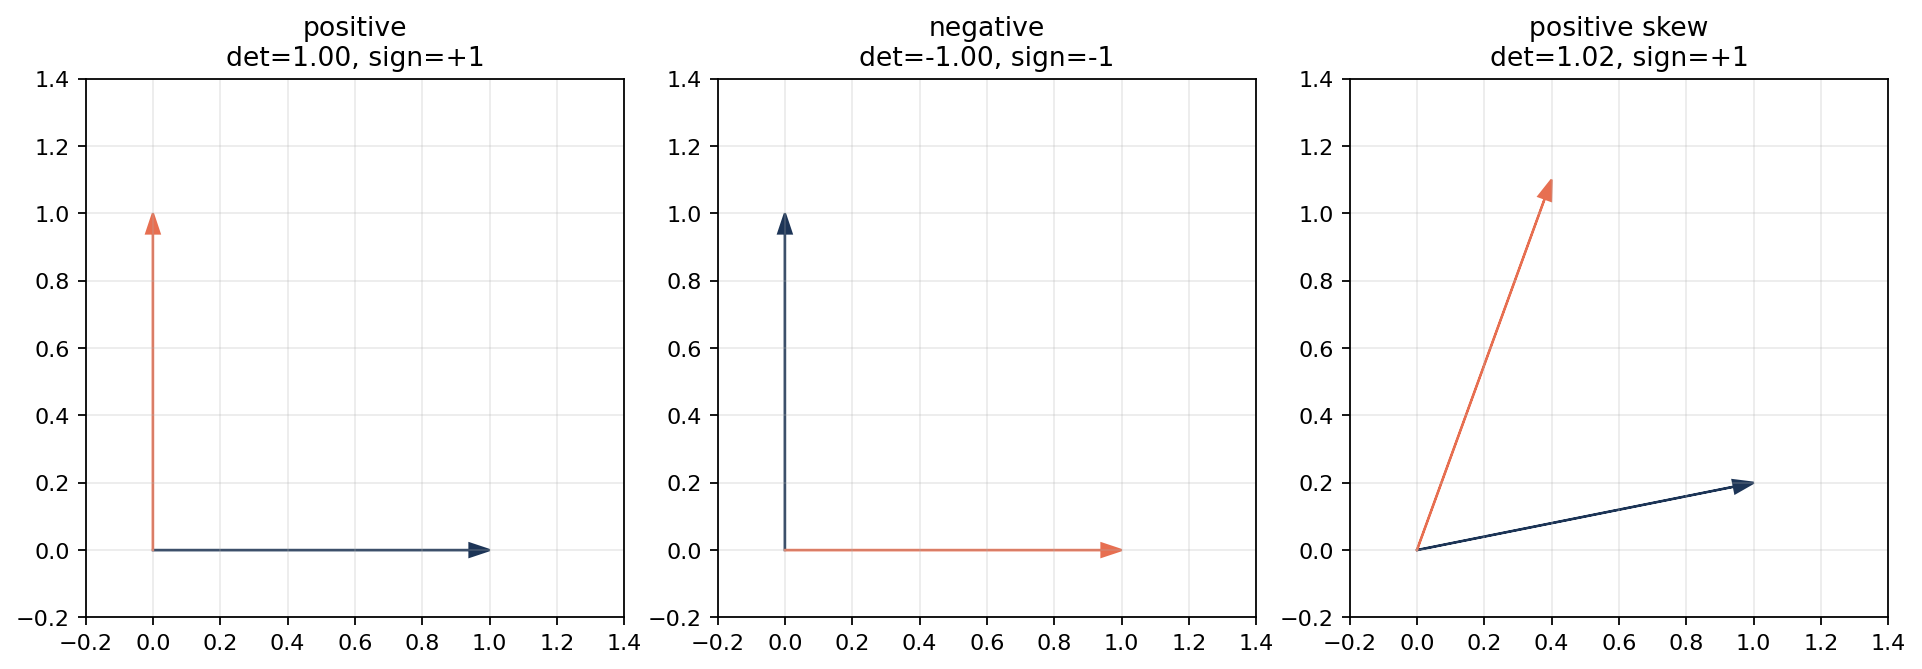

[{'frame': 'positive', 'determinant': 1.0, 'sign': 1},
 {'frame': 'negative', 'determinant': -1.0, 'sign': -1},
 {'frame': 'positive skew', 'determinant': 1.02, 'sign': 1}]

In [2]:
frames=[(np.eye(2),'positive'),(np.array([[0,1],[1,0]]),'negative'),(np.array([[1,.4],[.2,1.1]]),'positive skew')]
frame_rows=[]
fig,axes=plt.subplots(1,3,figsize=(12,4))
for ax,(B,label) in zip(axes,frames):
    det=float(np.linalg.det(B)); sign=1 if det>0 else -1
    for j,c in enumerate(['#1d3557','#e76f51']): ax.arrow(0,0,B[0,j],B[1,j],head_width=.04,color=c,length_includes_head=True)
    ax.set_title(f'{label}\ndet={det:.2f}, sign={sign:+d}'); ax.set_aspect('equal'); ax.set_xlim(-.2,1.4); ax.set_ylim(-.2,1.4); ax.grid(alpha=.25)
    frame_rows.append({'frame':label,'determinant':det,'sign':sign})
fig.tight_layout(); orient_path=save_matplotlib(fig, FIGURES/'orientation-frame-and-boundary-signs.png'); plt.close(fig)
orient_json=save_json({'rows':frame_rows,'interval_boundary_sum':-1+1}, CHECKS/'orientation-frame-and-boundary-signs.json')
TRACKED_ARTIFACTS.extend([orient_path,orient_json]); display_artifact(orient_path,width=840)
frame_rows


In [3]:
A=np.array([[1.1,.35],[.15,.8]]); b=np.array([.2,-.1]); detA=float(np.linalg.det(A))
centroid=A@np.array([.5,.5])+b
source_integral=float((centroid[0]**2+centroid[1])*detA)
target_integral=source_integral
square=np.array([[0,0],[1,0],[1,1],[0,1],[0,0]],float); para=square@A.T+b
fig=go.Figure(); fig.add_trace(go.Scatter(x=square[:,0],y=square[:,1],mode='lines+markers',name='source square')); fig.add_trace(go.Scatter(x=para[:,0],y=para[:,1],mode='lines+markers',name='chart image'))
fig.update_layout(title='Pullback integration through an affine chart',width=760,height=560,yaxis_scaleanchor='x')
pull_html=save_plotly_html(fig, HTML/'pullback-integration-affine-chart.html')
pull_json=save_json({'determinant':detA,'source_pullback_integral':source_integral,'target_integral':target_integral,'residual':abs(source_integral-target_integral)}, CHECKS/'pullback-integration-affine-chart.json')
TRACKED_ARTIFACTS.extend([pull_html,pull_json]); display_artifact(pull_html,width=800,height=560)
{'determinant':detA,'residual':abs(source_integral-target_integral)}


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'determinant': 0.8275000000000001, 'residual': 0.0}

## Stokes And de Rham Cohomology

Stokes theorem is the organizing theorem of this chapter: the integral of `d omega` over a chain equals the integral of `omega` over the boundary. Since exact forms integrate to zero over cycles, a closed form with a nonzero period detects a nontrivial de Rham cohomology class. The disk computation verifies Stokes; the punctured-plane angular form verifies a global obstruction.


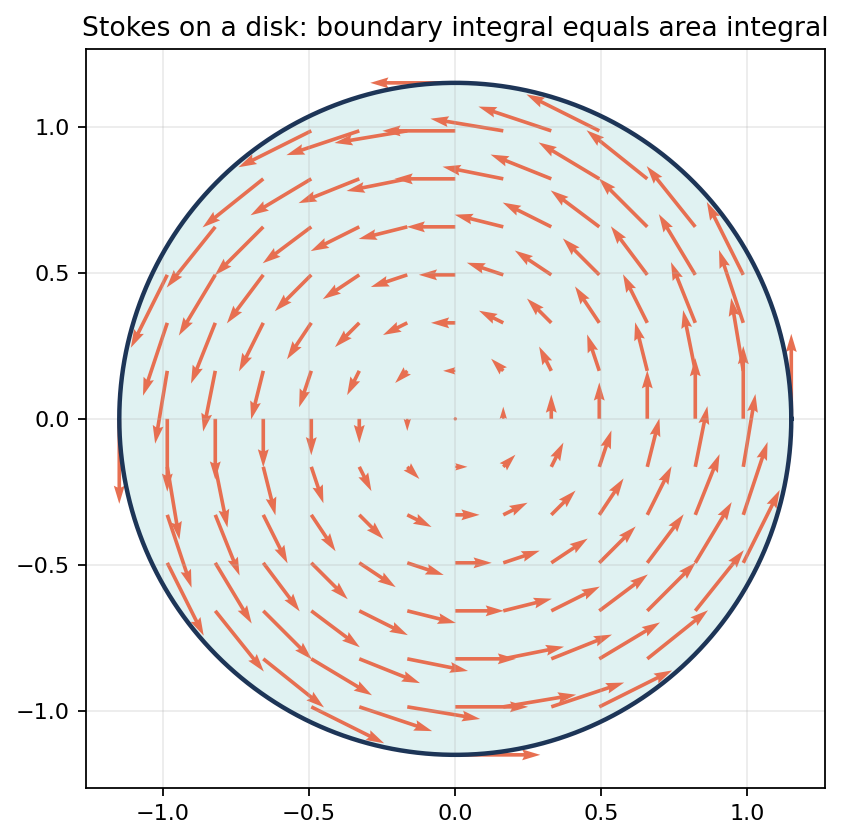

{'residual': 0.0, 'd2': 0}

In [4]:
r=1.15; th=np.linspace(0,2*np.pi,2001); x=r*np.cos(th); y=r*np.sin(th); dx=-r*np.sin(th); dy=r*np.cos(th)
P=-y/2; Q=x/2
boundary=float(np.trapezoid(P*dx+Q*dy,th)); area=math.pi*r*r
sx,sy=sp.symbols('x y'); f=sx**2*sy+sp.sin(sx+sy); d2=sp.simplify(sp.diff(sp.diff(f,sy),sx)-sp.diff(sp.diff(f,sx),sy))
X,Y=np.meshgrid(np.linspace(-r,r,15),np.linspace(-r,r,15)); mask=X*X+Y*Y<=r*r
fig,ax=plt.subplots(figsize=(6.5,6)); ax.add_patch(plt.Circle((0,0),r,color='#a8dadc',alpha=.35)); ax.plot(x,y,color='#1d3557',lw=2); ax.quiver(X[mask],Y[mask],(-Y/2)[mask],(X/2)[mask],color='#e76f51',scale=5); ax.set_aspect('equal'); ax.grid(alpha=.25); ax.set_title('Stokes on a disk: boundary integral equals area integral')
stokes_path=save_matplotlib(fig, FIGURES/'stokes-disk-boundary-integral.png'); plt.close(fig)
stokes_json=save_json({'area_integral':area,'boundary_integral':boundary,'residual':abs(area-boundary),'d_squared_sample':str(d2)}, CHECKS/'stokes-disk-boundary-integral.json')
TRACKED_ARTIFACTS.extend([stokes_path,stokes_json]); display_artifact(stokes_path,width=680)
{'residual':abs(area-boundary),'d2':d2}


In [5]:
th=np.linspace(0,2*np.pi,2001)
periods=[]
for rad in [.7,1.2,1.7]:
    x=rad*np.cos(th); y=rad*np.sin(th); dx=-rad*np.sin(th); dy=rad*np.cos(th)
    period=float(np.trapezoid((-y/(x*x+y*y))*dx+(x/(x*x+y*y))*dy,th))
    periods.append({'radius':rad,'period':period,'period_over_2pi':period/(2*math.pi)})
grid=np.linspace(-1.8,1.8,18); X,Y=np.meshgrid(grid,grid); R2=X*X+Y*Y; mask=R2>.2
fig=go.Figure(); fig.add_trace(go.Scatter(x=[0],y=[0],mode='markers+text',text=['puncture'],marker=dict(color='red',size=10)))
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        if mask[i,j]:
            u=-Y[i,j]/np.sqrt(R2[i,j]); v=X[i,j]/np.sqrt(R2[i,j]); fig.add_trace(go.Scatter(x=[X[i,j],X[i,j]+.13*u],y=[Y[i,j],Y[i,j]+.13*v],mode='lines',line=dict(color='#457b9d',width=1),showlegend=False))
fig.update_layout(title='Closed non-exact angular form: nonzero period around puncture',width=760,height=620,yaxis_scaleanchor='x')
period_html=save_plotly_html(fig, HTML/'angular-form-de-rham-period.html')
period_csv=save_csv(periods, TABLES/'angular-form-de-rham-period.csv')
period_json=save_json({'periods':periods,'max_error_from_one':max(abs(p['period_over_2pi']-1) for p in periods)}, CHECKS/'angular-form-de-rham-period.json')
TRACKED_ARTIFACTS.extend([period_html,period_csv,period_json]); display_artifact(period_html,width=800,height=620)
periods


[{'radius': 0.7, 'period': 6.283185307179586, 'period_over_2pi': 1.0},
 {'radius': 1.2, 'period': 6.283185307179586, 'period_over_2pi': 1.0},
 {'radius': 1.7, 'period': 6.283185307179586, 'period_over_2pi': 1.0}]

## Source Coverage Notes

This chapter has two integration settings: integration of forms over differentiable singular chains and integration over regular domains in oriented manifolds. Both depend on the same mechanism shown in the pullback lab: a parametrization pulls a form to a standard domain, and the orientation determines the sign. The disk computation is a concrete Stokes example, but it also stands for the general chain statement that boundary and exterior derivative are dual operations.

The de Rham portion begins after Stokes. Closed forms are those killed by `d`; exact forms are those already produced by `d`. Stokes explains why exact forms have zero periods on cycles. The angular-form example shows why local exactness is not the whole story: the form is closed away from the puncture and locally exact on small contractible patches, yet its global period is nonzero. That is the cohomological obstruction that Chapter 5 compares with sheaf and singular cohomology.


## Applied Lab: What Integration Knows

The chapter's computational pattern is: choose an orientation, write the form in a chart, pull it back, integrate, and compare with a boundary or cohomology statement. If the form is exact, Stokes makes its period over a cycle vanish. If a closed form has a nonzero period, the obstruction is global and belongs to de Rham cohomology. This is the bridge to Chapter 5, where de Rham cohomology is compared with sheaf and singular cohomology.


## Learner Inspection Targets

The notebook's integrals are small enough to recompute by hand. Inspect where the orientation enters: the frame determinant in the first visual, the Jacobian determinant in the pullback cell, and the counterclockwise boundary orientation in Stokes. Then compare exactness and closedness. The disk form is exact enough for Stokes to turn its derivative into a boundary integral; the angular form is closed but not globally exact because the puncture prevents a single-valued angle function.

Warner also discusses integration on Riemannian manifolds and Lie groups. The local examples here are the computational primitives behind those settings: volume forms from metrics, invariant forms on groups, and periods of closed forms over cycles.

The exercises at the end of the source span extend these ideas through homotopy operators and concrete computations. For this notebook, those exercises are represented by the dependency graph and by the angular-period lab: both show how a local formula becomes a global invariant only after the correct chains, boundaries, and homotopies are tracked.


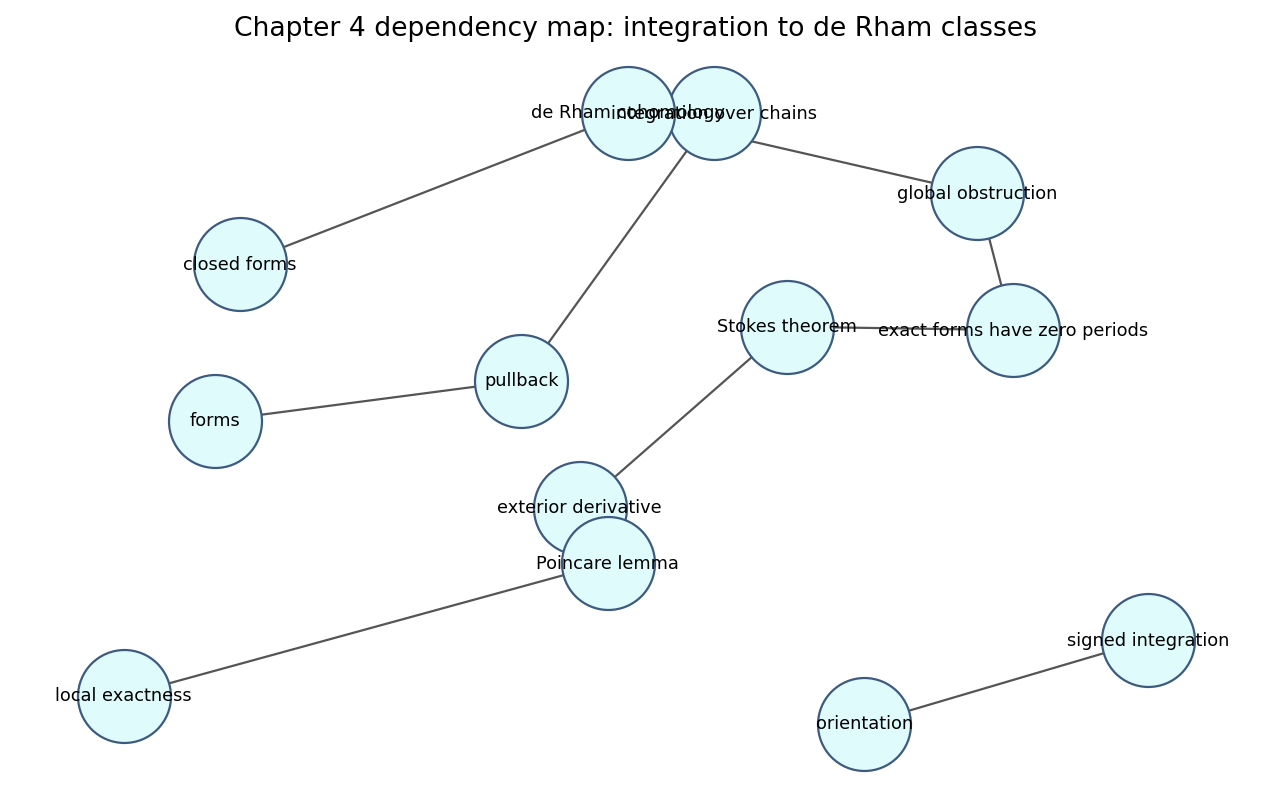

{'nodes': 13, 'edges': 9}

In [6]:
G=nx.DiGraph(); edges=[('orientation','signed integration'),('forms','pullback'),('pullback','integration over chains'),('exterior derivative','Stokes theorem'),('Stokes theorem','exact forms have zero periods'),('exact forms have zero periods','global obstruction'),('closed forms','de Rham cohomology'),('Poincare lemma','local exactness'),('de Rham cohomology','global obstruction')]
G.add_edges_from(edges); pos=nx.spring_layout(G,seed=404,k=.85)
fig,ax=plt.subplots(figsize=(10,6)); nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',edge_color='#555'); nx.draw_networkx_nodes(G,pos,ax=ax,node_color='#e0fbfc',edgecolors='#3d5a80',node_size=1750); nx.draw_networkx_labels(G,pos,ax=ax,font_size=8); ax.axis('off'); ax.set_title('Chapter 4 dependency map: integration to de Rham classes')
dep_path=save_matplotlib(fig, FIGURES/'integration-stokes-de-rham-dependency-map.png'); plt.close(fig)
dep_json=save_json({'nodes':list(G.nodes),'edges':edges,'acyclic':nx.is_directed_acyclic_graph(G)}, CHECKS/'integration-stokes-de-rham-dependency-map.json')
TRACKED_ARTIFACTS.extend([dep_path,dep_json]); display_artifact(dep_path,width=780)
{'nodes':G.number_of_nodes(),'edges':G.number_of_edges()}


In [7]:
assert frame_rows[0]['sign']==1 and frame_rows[1]['sign']==-1
assert abs(source_integral-target_integral)<1e-12
assert abs(area-boundary)<1e-4 and str(d2)=='0'
assert max(abs(p['period_over_2pi']-1) for p in periods)<1e-5
assert nx.has_path(G,'exterior derivative','global obstruction')
assert_artifacts(TRACKED_ARTIFACTS,min_bytes=80)
final_sanity={'unit':UNIT_KEY,'tracked_artifacts':len(TRACKED_ARTIFACTS),'core_checks':['orientation signs','pullback integration','Stokes residual','de Rham period obstruction','proof DAG']}
final_sanity


{'unit': 'chapter-04-integration-on-manifolds',
 'tracked_artifacts': 11,
 'core_checks': ['orientation signs',
  'pullback integration',
  'Stokes residual',
  'de Rham period obstruction',
  'proof DAG']}

## Takeaways

Integration on manifolds is coordinate-free because forms pull back naturally and orientations control signs. Stokes theorem turns exterior differentiation into a boundary operation. de Rham cohomology records closed forms modulo exact forms, so nonzero periods around cycles detect global topology. Warner's later de Rham theorem chapter expands this analytic cohomology into a comparison with sheaf and singular theories.
